In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df=pd.read_csv("Exam_Score_Prediction.csv")

In [12]:
df.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [9]:
df.columns

Index(['student_id', 'age', 'gender', 'course', 'study_hours',
       'class_attendance', 'internet_access', 'sleep_hours', 'sleep_quality',
       'study_method', 'facility_rating', 'exam_difficulty', 'exam_score'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  int64  
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  object 
 3   course            20000 non-null  object 
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  object 
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  object 
 9   study_method      20000 non-null  object 
 10  facility_rating   20000 non-null  object 
 11  exam_difficulty   20000 non-null  object 
 12  exam_score        20000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 2.0+ MB


In [11]:
df.describe()

,student_id,age,study_hours,class_attendance,sleep_hours,exam_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000
mean,10000.504600,20.473300,4.007604,70.017365,7.00856,62.513225
std,5773.654959,2.284458,2.308313,17.282262,1.73209,18.908491
min,1.000000,17.000000,0.080000,40.600000,4.10000,19.599000
25%,5000.750000,18.000000,2.000000,55.100000,5.50000,48.800000
50%,10000.500000,20.000000,4.040000,69.900000,7.00000,62.600000
75%,15000.250000,22.000000,6.000000,85.000000,8.50000,76.300000
max,20001.000000,24.000000,7.910000,99.400000,9.90000,100.000000


In [17]:
df.isnull().sum()

student_id          0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64

In [19]:
df.duplicated().sum()

np.int64(0)

In [21]:
df=df.drop('student_id',axis=1)

In [22]:
df.columns

Index(['age', 'gender', 'course', 'study_hours', 'class_attendance',
       'internet_access', 'sleep_hours', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty', 'exam_score'],
      dtype='object')

In [23]:
from sklearn.preprocessing import LabelEncoder

In [24]:
le=LabelEncoder()

In [28]:
df.select_dtypes(include='object').columns

Index(['gender', 'course', 'internet_access', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty'],
      dtype='object')

In [33]:
df['gender']=le.fit_transform(df['gender'])

In [34]:
df['gender'].head()

0    1
1    2
2    1
3    2
4    0
Name: gender, dtype: int64

In [35]:
cat_cols=df.select_dtypes(include='object').columns

In [36]:
cat_cols

Index(['course', 'internet_access', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty'],
      dtype='object')

In [37]:
for col in cat_cols:
    df[col]=le.fit_transform(df[col])

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               20000 non-null  int64  
 1   gender            20000 non-null  int64  
 2   course            20000 non-null  int64  
 3   study_hours       20000 non-null  float64
 4   class_attendance  20000 non-null  float64
 5   internet_access   20000 non-null  int64  
 6   sleep_hours       20000 non-null  float64
 7   sleep_quality     20000 non-null  int64  
 8   study_method      20000 non-null  int64  
 9   facility_rating   20000 non-null  int64  
 10  exam_difficulty   20000 non-null  int64  
 11  exam_score        20000 non-null  float64
dtypes: float64(4), int64(8)
memory usage: 1.8 MB


In [39]:
X=df.drop('exam_score',axis=1)

In [42]:
X.head(1)

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
0,17,1,6,2.78,92.9,1,7.4,2,0,1,1


In [44]:
y=df['exam_score']

In [47]:
from sklearn.model_selection import train_test_split

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [49]:
X_train.shape

(16000, 11)

In [50]:
X_test.shape

(4000, 11)

In [51]:
from sklearn.linear_model import LinearRegression

In [52]:
lr = LinearRegression()

In [53]:
lr.fit(X_train, y_train)

LinearRegression()

In [54]:
y_pred = lr.predict(X_test)

In [55]:
y_pred[:5]

array([35.98941727, 71.3917643 , 52.90322633, 93.42841899, 80.74939513])

In [56]:
from sklearn.metrics import mean_squared_error, r2_score

In [59]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

In [60]:
rmse

np.float64(10.90656392004086)

In [61]:
r2 = r2_score(y_test, y_pred)

In [62]:
r2

0.6674472231649904

In [63]:
from sklearn.ensemble import RandomForestRegressor

In [64]:
rf = RandomForestRegressor(random_state=42)

In [68]:
rf_pred = rf.predict(X_test)

In [69]:
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [66]:
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [70]:
rf_pred[:5]

array([34.32689, 74.03   , 56.626  , 96.005  , 83.995  ])

In [71]:
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

In [72]:
rf_rmse

np.float64(10.520062872450195)

In [73]:
rf_r2 = r2_score(y_test, rf_pred)

In [74]:
rf_r2

0.690599257677559

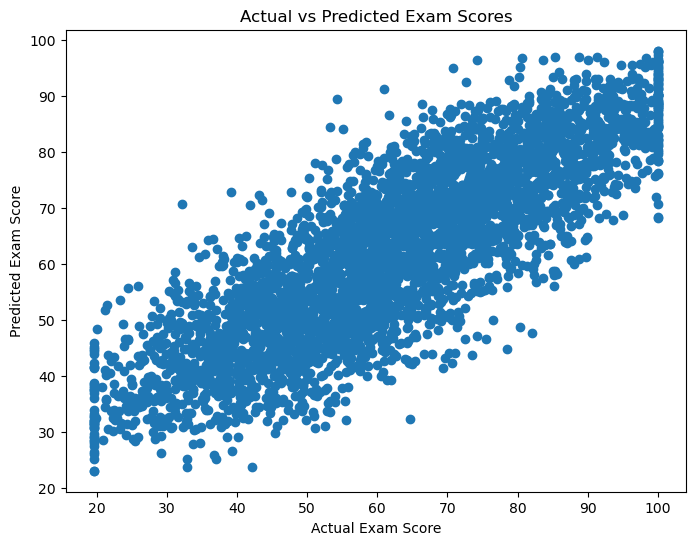

In [78]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_pred)

plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')

plt.title('Actual vs Predicted Exam Scores')

plt.show()

In [79]:
importance = rf.feature_importances_

In [80]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

In [81]:
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

In [82]:
feature_importance.head()

,Feature,Importance
3,study_hours,0.572267
4,class_attendance,0.158625
6,sleep_hours,0.068125
8,study_method,0.045204
7,sleep_quality,0.040760


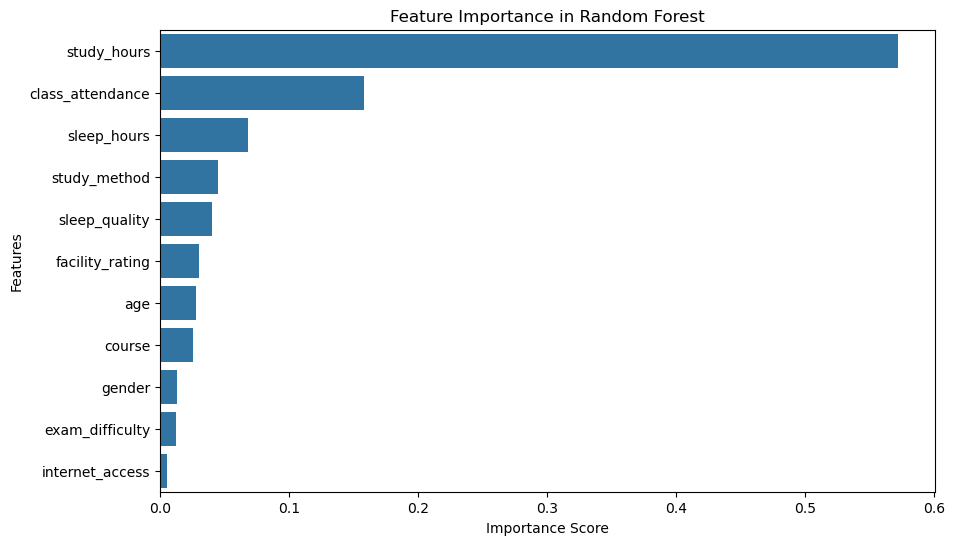

In [85]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title('Feature Importance in Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.show()

In [87]:
print("Linear Regression RMSE:", rmse)
print("Linear Regression R2 Score:", r2)

print()

print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2 Score:", rf_r2)

Linear Regression RMSE: 10.90656392004086
Linear Regression R2 Score: 0.6674472231649904

Random Forest RMSE: 10.520062872450195
Random Forest R2 Score: 0.690599257677559
